# Apresentando o Banco de Dados
- https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce?select=olist_customers_dataset.csv
    - Já disponível no banco de dados `vendas_db.db` através do link:
        - https://drive.google.com/file/d/1eONzrbEu5BoijDRj56gjL_2Ik5qxtR6U/view?usp=sharing

In [1]:
# Importando o sqlite e o pandas
import sqlite3
import pandas as pd

In [13]:
# Criando uma conexão
con = sqlite3.connect('../data/vendas_db.db')

In [14]:
# Criando o cursor
cur = con.cursor()

In [15]:
# Utilizando a função que já criamos
def executa_consulta(consulta):
    resultado = cur.execute(consulta).fetchall()
    resultado = pd.DataFrame(resultado)
    colunas = [i[0] for i in cur.description]
    if resultado.shape[1] > 0:
        resultado.columns = colunas
    print(resultado.shape)
    display(resultado.head(3))
    return resultado

**Para visualizar as tabelas que existem no banco, podemos consultar o `sqlite_schema`**

In [16]:
# Verificando as tabelas existentes no banco de dados
executa_consulta('SELECT * FROM sqlite_schema WHERE type = "table"')

(9, 5)


,type,name,tbl_name,rootpage,sql
0,table,order_payments,order_payments,2,"CREATE TABLE ""order_payments"" (\n""index"" INTEG..."
1,table,customers,customers,7037,"CREATE TABLE ""customers"" (\n""index"" INTEGER,\n..."
2,table,geolocation,geolocation,9679,"CREATE TABLE ""geolocation"" (\n""index"" INTEGER,..."


,type,name,tbl_name,rootpage,sql
0,table,order_payments,order_payments,2,"CREATE TABLE ""order_payments"" (\n""index"" INTEG..."
1,table,customers,customers,7037,"CREATE TABLE ""customers"" (\n""index"" INTEGER,\n..."
2,table,geolocation,geolocation,9679,"CREATE TABLE ""geolocation"" (\n""index"" INTEGER,..."
3,table,order_items,order_items,24605,"CREATE TABLE ""order_items"" (\n""index"" INTEGER,..."
4,table,sellers,sellers,29140,"CREATE TABLE ""sellers"" (\n""index"" INTEGER,\n ..."
5,table,product_category_name_translation,product_category_name_translation,29197,"CREATE TABLE ""product_category_name_translatio..."
6,table,products,products,29199,"CREATE TABLE ""products"" (\n""index"" INTEGER,\n ..."
7,table,order_reviews,order_reviews,29893,"CREATE TABLE ""order_reviews"" (\n""index"" INTEGE..."
8,table,orders,orders,2021,"CREATE TABLE ""orders"" (\n""index"" INTEGER,\n ""..."


In [17]:
# Verificando a base de avaliações
avaliacoes = executa_consulta('SELECT * FROM order_reviews')

(99224, 8)


,index,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24


In [18]:
avaliacoes.head(3)

,index,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24


**Podemos visualizar todo o esquema de tabelas do nosso banco**

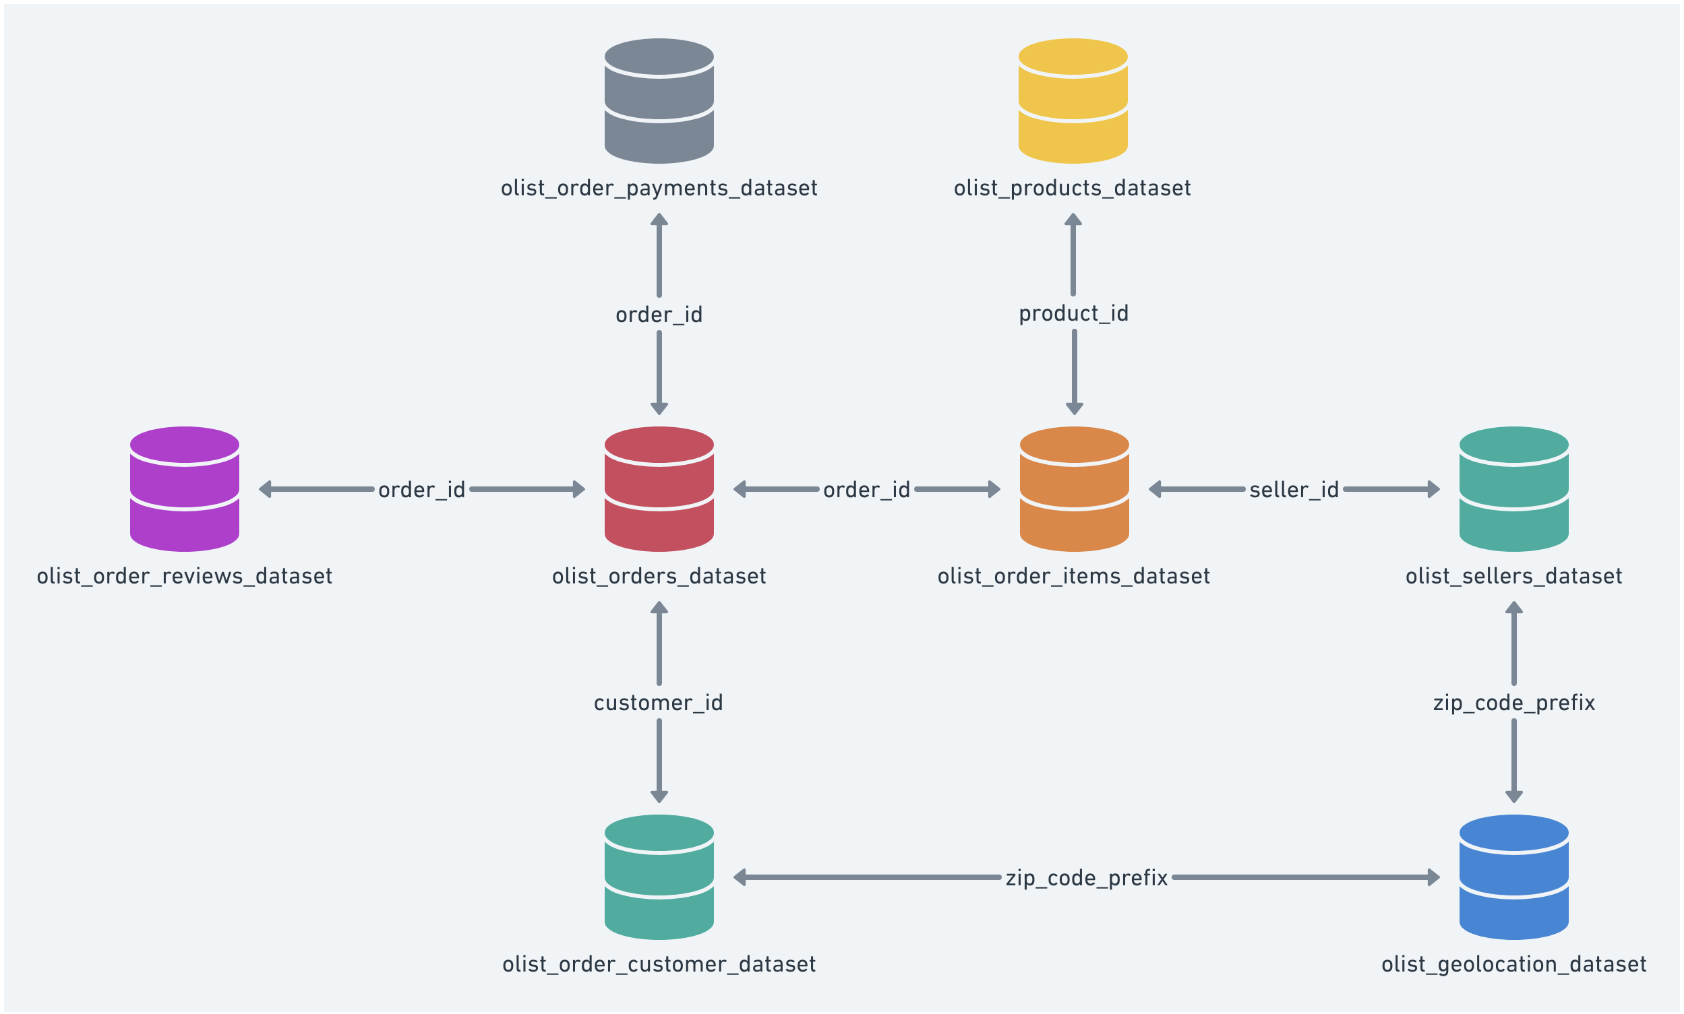

In [19]:
# Já trazendo a avaliação e o pedido
avaliacoes_pedido = executa_consulta('SELECT * FROM order_reviews ore \
                                    LEFT JOIN orders o \
                                    ON ore.order_id = o.order_id \
                                    LEFT JOIN order_items oi \
                                    ON o.order_id = oi.order_id')

(113131, 25)


,index,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,index,order_id,...,order_delivered_customer_date,order_estimated_delivery_date,index,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59,1871,73fc7af87114b39712e6da79b0a377eb,...,2018-01-17 18:42:41,2018-02-02 00:00:00,51033.0,73fc7af87114b39712e6da79b0a377eb,1.0,fd25ab760bfbba13c198fa3b4f1a0cd3,6d803cb79cc31c41c4c789a75933b3c7,2018-01-18 15:47:59,185.00,13.63
1,0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59,1871,73fc7af87114b39712e6da79b0a377eb,...,2018-01-17 18:42:41,2018-02-02 00:00:00,51034.0,73fc7af87114b39712e6da79b0a377eb,2.0,fd25ab760bfbba13c198fa3b4f1a0cd3,6d803cb79cc31c41c4c789a75933b3c7,2018-01-18 15:47:59,185.00,13.63
2,1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13,90488,a548910a1c6147796b98fdf73dbeba33,...,2018-03-09 23:17:20,2018-03-14 00:00:00,72472.0,a548910a1c6147796b98fdf73dbeba33,1.0,be0dbdc3d67d55727a65d4cd696ca73c,8e6d7754bc7e0f22c96d255ebda59eba,2018-03-06 12:48:39,79.79,8.30


In [20]:
# Fazendo a média de venda por avaliação
avaliacoes_pedido.groupby('review_score')['price'].mean()

review_score
1    127.350068
2    115.849138
3    110.059704
4    118.602628
5    121.219825
Name: price, dtype: float64

In [21]:
# Executando essa consulta agora no SQL
avaliacoes_pedido_mean = executa_consulta('SELECT review_score, AVG(price) as media_preco \
                                    FROM order_reviews ore \
                                    LEFT JOIN orders o \
                                    ON ore.order_id = o.order_id \
                                    LEFT JOIN order_items oi \
                                    ON o.order_id = oi.order_id \
                                    GROUP BY review_score')

(5, 2)


,review_score,media_preco
0,1,127.350068
1,2,115.849138
2,3,110.059704


In [22]:
avaliacoes_pedido_mean

,review_score,media_preco
0,1,127.350068
1,2,115.849138
2,3,110.059704
3,4,118.602628
4,5,121.219825
